In [3]:
import pandas as pd


train_df = pd.read_csv('train.csv')

test_df = pd.read_csv('test.csv')


print("Train Data Head:")
print(train_df.head())
print("\n")


print("Train Data Info:")
train_df.info()
print("\n")


print("Test Data Head:")
print(test_df.head())
print("\n")


print("Test Data Info:")
test_df.info()



X_train = train_df.drop(['ID', 'class'], axis=1)
y_train = train_df['class']

#Удаляем ID
X_test = test_df.drop('ID', axis=1)

# Идентификация категориальных столбцов
categorical_cols = [
    'sex',
    'fasting_blood_sugar',
    'resting_electrocardiographic_results',
    'exercise_induced_angina',
    'slope',
    'number_of_major_vessels',
    'thal'
]

# Преобразование категориальных переменных в фиктивные переменные для обучающих данных
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Преобразование категориальных переменных в фиктивные переменные для тестовых данных
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)


print("\nPreprocessed Train Data Head:")
print(X_train.head())
print("\n")


print("Preprocessed Train Data Info:")
X_train.info()
print("\n")


print("Preprocessed Test Data Head:")
print(X_test.head())
print("\n")

print("Preprocessed Test Data Info:")
X_test.info()

Train Data Head:
   ID        age  sex     chest  resting_blood_pressure  serum_cholestoral  \
0   0  49.207124    0  4.000000              162.996167         181.108682   
1   1  53.628425    1  1.741596              130.233730         276.474630   
2   2  49.591426    1  4.000000              146.999012         223.300517   
3   3  58.991445    1  4.000000              112.369143         187.245501   
4   4  51.053602    1  1.954609              138.032047         238.482868   

   fasting_blood_sugar  resting_electrocardiographic_results  \
0                    0                                     0   
1                    0                                     2   
2                    1                                     2   
3                    0                                     0   
4                    0                                     0   

   maximum_heart_rate_achieved  exercise_induced_angina   oldpeak  slope  \
0                   148.227858                       

In [6]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Лог регрессия
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)


print("Training Logistic Regression model...")
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained.")


log_reg_predictions = log_reg_model.predict(X_test)
log_reg_probabilities = log_reg_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Predictions (first 5):")
print(log_reg_predictions[:5])
print("\nLogistic Regression Probabilities (first 5, class 1):\n", log_reg_probabilities[:5])

Training Logistic Regression model...
Logistic Regression model trained.

Logistic Regression Predictions (first 5):
[1 1 0 0 0]

Logistic Regression Probabilities (first 5, class 1):
 [0.98336253 0.97421658 0.01495316 0.44914465 0.02231435]


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Случайный лес
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


print("Training RandomForest Classifier model...")
rf_model.fit(X_train, y_train)
print("RandomForest Classifier model trained.")


rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("\nRandomForest Classifier Predictions (first 5):")
print(rf_predictions[:5])
print("\nRandomForest Classifier Probabilities (first 5, class 1):\n", rf_probabilities[:5])

Training RandomForest Classifier model...
RandomForest Classifier model trained.

RandomForest Classifier Predictions (first 5):
[1 1 0 0 0]

RandomForest Classifier Probabilities (first 5, class 1):
 [0.99 0.97 0.01 0.21 0.01]


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Neural Network
#
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


n_features = X_train_scaled.shape[1]
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)), # Input layer
    Dense(64, activation='relu'), # Hidden layer
    Dense(1, activation='sigmoid') # Output layer for binary classification
])


nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


print("Training Neural Network model...")

history = nn_model.fit(X_train_scaled, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=0)
print("Neural Network model trained.")


nn_probabilities = nn_model.predict(X_test_scaled).flatten()
nn_predictions = (nn_probabilities > 0.5).astype(int)

print("\nNeural Network Predictions (first 5):")
print(nn_predictions[:5])
print("\nNeural Network Probabilities (first 5):\n", nn_probabilities[:5])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Neural Network model...
Neural Network model trained.
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step

Neural Network Predictions (first 5):
[1 1 0 0 0]

Neural Network Probabilities (first 5):
 [0.98591524 0.985355   0.01308781 0.28485003 0.0139279 ]


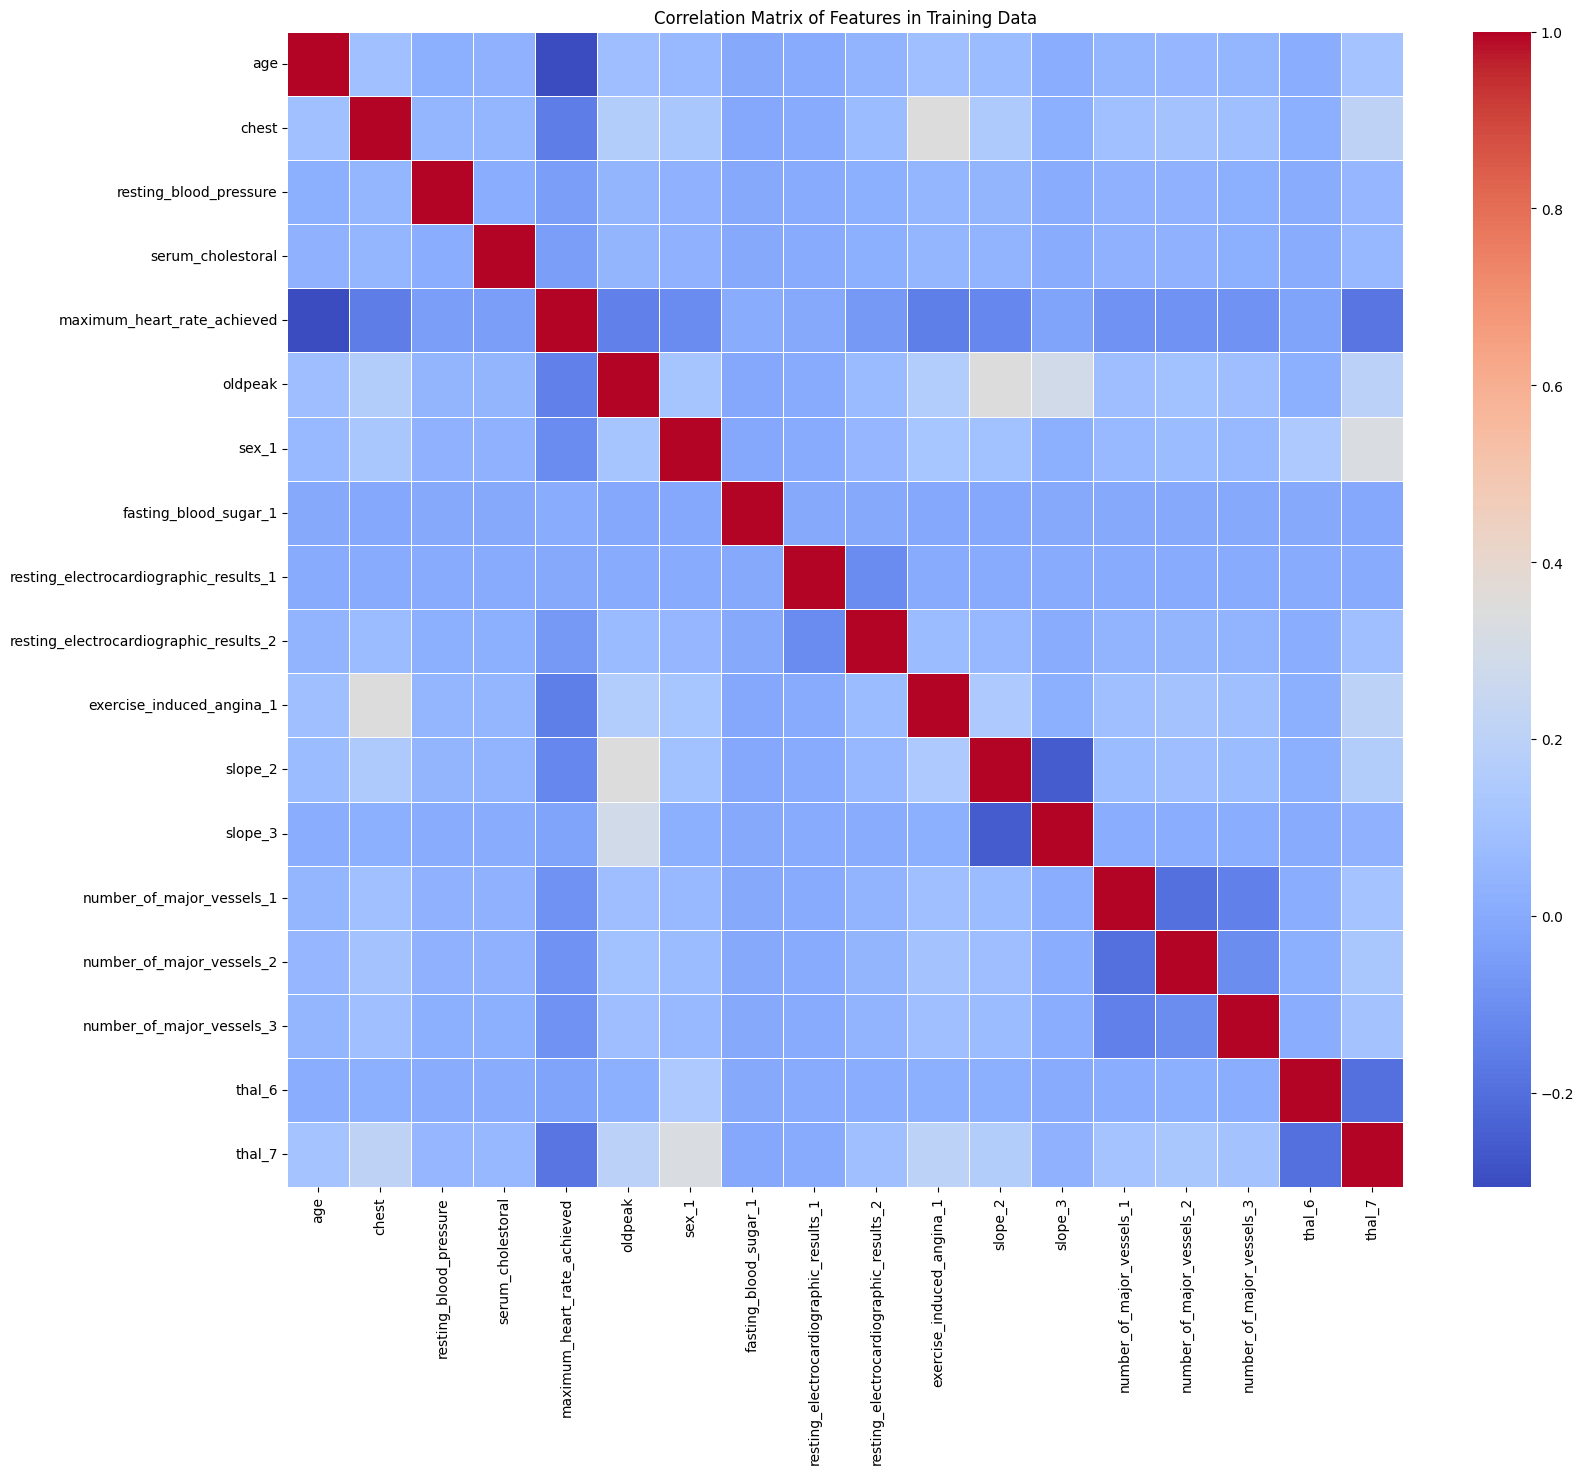

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Корр матрица
correlation_matrix = X_train.corr()

# тепловая карта
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features in Training Data')
plt.show()

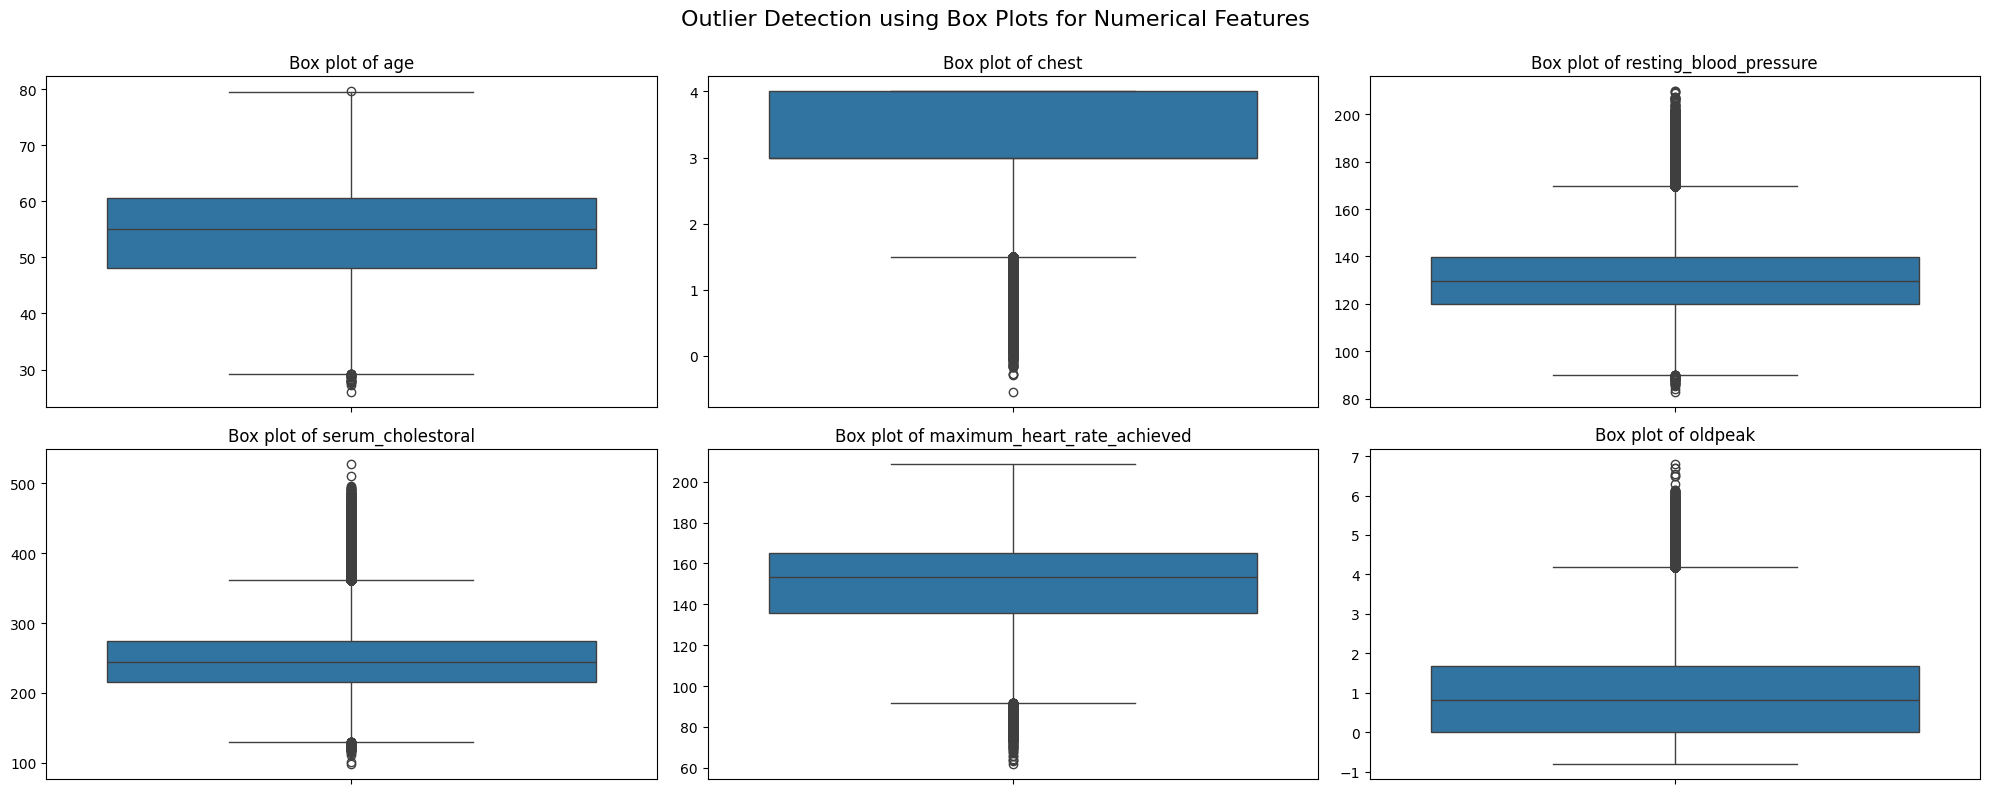

In [5]:

numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

# Боксплоты
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=X_train[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Outlier Detection using Box Plots for Numerical Features', y=1.02, fontsize=16)
plt.show()

In [9]:
import os


model_artifacts_dir = 'model_artifacts'
os.makedirs(model_artifacts_dir, exist_ok=True)

# Загрузите лучшие веса выбранной модели
weights_path = os.path.join(model_artifacts_dir, 'nn_model_weights.weights.h5')
nn_model.save_weights(weights_path)
print(f"Neural Network model weights saved to {weights_path}")

Neural Network model weights saved to model_artifacts/nn_model_weights.weights.h5


In [10]:
import joblib


scaler_path = os.path.join(model_artifacts_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

Scaler saved to model_artifacts/scaler.pkl


In [12]:
#подготовьте скрипт для инференса
inference_script_content = """
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import joblib
import pandas as pd
import numpy as np
import os

# --- Configuration (must match training setup) ---
MODEL_ARTIFACTS_DIR = 'model_artifacts'
NN_WEIGHTS_PATH = os.path.join(MODEL_ARTIFACTS_DIR, 'nn_model_weights.weights.h5')
SCALER_PATH = os.path.join(MODEL_ARTIFACTS_DIR, 'scaler.pkl')

# List of original categorical columns used for one-hot encoding
CATEGORICAL_COLS = [
    'sex',
    'fasting_blood_sugar',
    'resting_electrocardiographic_results',
    'exercise_induced_angina',
    'slope',
    'number_of_major_vessels',
    'thal'
]

# The exact order of columns after preprocessing during training
# This is crucial for consistent input to the Neural Network.
# Derived from X_train.columns after one-hot encoding.
TRAINING_COLUMNS = ['age', 'chest', 'resting_blood_pressure', 'serum_cholestoral',
       'maximum_heart_rate_achieved', 'oldpeak', 'sex_1',
       'fasting_blood_sugar_1', 'resting_electrocardiographic_results_1',
       'resting_electrocardiographic_results_2', 'exercise_induced_angina_1',
       'slope_1', 'slope_2', 'number_of_major_vessels_1',
       'number_of_major_vessels_2', 'number_of_major_vessels_3',
       'number_of_major_vessels_4', 'thal_7']

def build_nn_model(n_features):
    \"\"\"Reconstructs the Neural Network model architecture.\"\"\"
    model = Sequential([
        Dense(128, activation='relu', input_shape=(n_features,)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def preprocess_input(data_df, scaler, training_columns, categorical_cols):
    \"\"\"
    Preprocesses raw input data for prediction.
    Applies one-hot encoding and scaling.
    Ensures consistent column order with training data.
    \"\"\"
    # Ensure data_df is a DataFrame for consistent processing
    if isinstance(data_df, pd.Series):
        data_df = pd.DataFrame([data_df])
    elif not isinstance(data_df, pd.DataFrame):
        raise TypeError("Input data must be a pandas DataFrame or Series.")

    # Apply one-hot encoding
    # Use get_dummies with known columns and ensure consistent output
    data_encoded = pd.get_dummies(data_df, columns=categorical_cols, drop_first=True)

    # Reindex to ensure all columns from training are present, filling missing with 0
    # And ensuring the order is the same as TRAINING_COLUMNS
    data_processed = data_encoded.reindex(columns=training_columns, fill_value=0)

    # Scale numerical features
    data_scaled = scaler.transform(data_processed)

    return data_scaled

def load_model_and_scaler():
    \"\"\"Loads the trained NN model and the scaler.\"\"\"
    # Determine n_features based on the training columns length
    n_features = len(TRAINING_COLUMNS)

    # Load the scaler
    scaler = joblib.load(SCALER_PATH)

    # Build the model architecture
    nn_model = build_nn_model(n_features)

    # Load the weights
    nn_model.load_weights(NN_WEIGHTS_PATH)

    return nn_model, scaler

def predict(raw_data_df):
    \"\"\"
    Main prediction function. Takes raw DataFrame, preprocesses it,
    and returns predictions and probabilities.
    \"\"\"
    model, scaler = load_model_and_scaler()
    processed_data = preprocess_input(raw_data_df, scaler, TRAINING_COLUMNS, CATEGORICAL_COLS)
    probabilities = model.predict(processed_data).flatten()
    predictions = (probabilities > 0.5).astype(int)
    return predictions, probabilities


if __name__ == "__main__":
    print("Loading model and scaler...")
    model, scaler = load_model_and_scaler()
    print("Model and scaler loaded successfully.")

    # Example new data for prediction (mimics a row from the original test_df without 'ID')
    example_new_data = pd.DataFrame([
        {
            'age': 53.963191,
            'sex': 1,
            'chest': 4.0,
            'resting_blood_pressure': 136.940829,
            'serum_cholestoral': 236.862814,
            'fasting_blood_sugar': 0,
            'resting_electrocardiographic_results': 2,
            'maximum_heart_rate_achieved': 143.961525,
            'exercise_induced_angina': 1,
            'oldpeak': 1.637374,
            'slope': 1,
            'number_of_major_vessels': 0,
            'thal': 3
        },
        {
            'age': 49.621479,
            'sex': 1,
            'chest': 4.0,
            'resting_blood_pressure': 122.024651,
            'serum_cholestoral': 226.593019,
            'fasting_blood_sugar': 0,
            'resting_electrocardiographic_results': 2,
            'maximum_heart_rate_achieved': 112.220874,
            'exercise_induced_angina': 1,
            'oldpeak': 1.838571,
            'slope': 2,
            'number_of_major_vessels': 0,
            'thal': 3
        }
    ])


    print("\nExample new data:")
    print(example_new_data)

    # Preprocess the example data
    processed_data = preprocess_input(example_new_data, scaler, TRAINING_COLUMNS, CATEGORICAL_COLS)
    print("\nShape of processed data:", processed_data.shape)

    # Make predictions
    probabilities = model.predict(processed_data).flatten()
    predictions = (probabilities > 0.5).astype(int)

    print("\nPredictions for example data:")
    print(predictions)
    print("\nProbabilities for example data:")
    print(probabilities)

    # Demonstrate using the standalone predict function
    print("\nDemonstrating `predict` function:")
    pred_labels, pred_probs = predict(example_new_data)
    print("Predictions (using predict func):", pred_labels)
    print("Probabilities (using predict func):", pred_probs)
"""

with open('inference.py', 'w') as f:
    f.write(inference_script_content)

print("inference.py created successfully!")

inference.py created successfully!


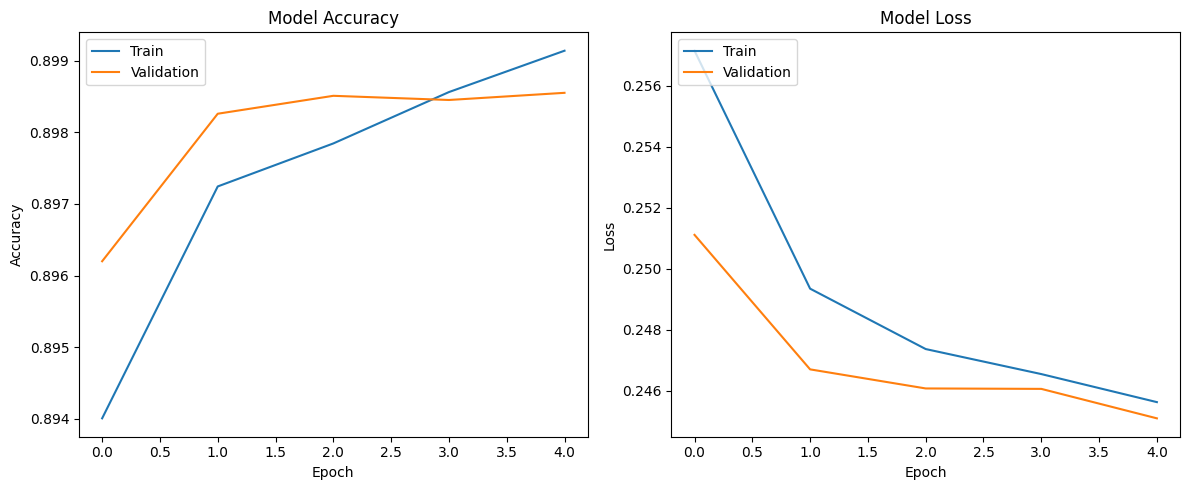

In [13]:
import matplotlib.pyplot as plt

# Добавьте графики обучения и результаты анализа данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
import subprocess


with open('requirements.txt', 'w') as f:
    subprocess.call(['pip', 'freeze'], stdout=f)

print("requirements.txt created successfully!")

requirements.txt created successfully!
